<div style="background-color:#00843D;padding:22px 28px;border-radius:12px;margin-bottom:4px">
  <h2 style="color:white;margin:0;font-size:22px">Analisis Numerico</h2>
  <p style="color:#b8f0c8;margin:6px 0 2px;font-size:14px">Universidad Nacional de Colombia - Sede Manizales</p>
  <p style="color:#b8f0c8;margin:0;font-size:14px">Prof. Carlos Manuel Orrego Franco</p>
</div>

---

# Notebook 03: Redes Neuronales con TensorFlow
## Capas, pesos, activaciones y backpropagation desde el concepto

---

### Objetivos de aprendizaje

Al finalizar este notebook seras capaz de:

1. **Explicar** que es el gradiente y por que es la clave del aprendizaje
2. **Entender** backpropagation como aplicacion de la regla de la cadena
3. **Identificar** que hace cada componente de una red: capas, pesos, activaciones
4. **Explicar** para que sirven flatten y padding en redes convolucionales
5. **Construir** una red multicapa con TensorFlow/Keras y entenderla celda por celda

### Prerequisitos

- Notebook 01 y 02 completados
- Derivadas y regla de la cadena
- Python, NumPy

---

> **Como leer este notebook:**
> - Las celdas **[OK]** estan listas: presiona `Shift+Enter`
> - Las celdas **[Ejercicio]** son para completar antes de continuar


## 1. De donde venimos: la pregunta abierta

En el Notebook 02 vimos que:

- Una sola neurona puede aprender problemas **linealmente separables** con la regla del Perceptron
- Para resolver XOR (y cualquier problema no lineal) necesitamos **varias capas**
- El obstacculo: con varias capas, la regla del Perceptron ya no sirve

La pregunta que quedo abierta fue:

> *"Si el error sale de la ultima capa, como sabe cada neurona interior*
> *cuanto contribuyo a ese error para poder corregirse?"*

Esa pregunta estuvo sin respuesta practica durante ~30 anos.
La solucion es el **algoritmo de backpropagation** (1986),
y requiere dos ingredientes que el Perceptron no tenia:

1. Una funcion de perdida diferenciable que mida el error
2. Funciones de activacion diferenciables (no el escalon discontinuo)

Empecemos por entender el gradiente -- la brujula del aprendizaje.


In [1]:
# [OK] Ejecuta esta celda primero

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2.0,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
})

VERDE   = "#00843D"
AZUL    = "#1a5fa8"
ROJO    = "#c0392b"
NARANJA = "#e67e22"
MORADO  = "#8e44ad"
GRIS    = "#7f8c8d"

np.random.seed(42)
print("Librerias cargadas.")


Librerias cargadas.


## 2. El gradiente: la brujula del aprendizaje

Toda la magia del aprendizaje profundo se reduce a una pregunta:

> *"Si cambio ligeramente el peso $w$, cuanto cambia el error?"*

Eso es exactamente la **derivada parcial** del error respecto al peso:
$\partial L / \partial w$.

El **gradiente** es el vector de todas esas derivadas parciales.
Apunta en la direccion en que el error **sube mas rapido**.
Por eso actualizamos los pesos en la **direccion opuesta** al gradiente:

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

Esto se llama **descenso por gradiente** (*gradient descent*).

| Signo del gradiente | Significa | Accion |
|--------------------|-----------|--------|
| $\partial L / \partial w > 0$ | subir $w$ sube el error | bajar $w$ |
| $\partial L / \partial w < 0$ | bajar $w$ sube el error | subir $w$ |
| $\partial L / \partial w = 0$ | $w$ no afecta el error | no hacer nada |

> **Conexion directa con lo visto en clase:** el descenso por gradiente
> es el metodo de Euler aplicado a la ODE $\dot{w} = -\nabla L(w)$.
> El "tiempo" es el numero de pasos de entrenamiento,
> y "h" es la tasa de aprendizaje $\eta$.
> Las Neural ODEs (Notebook 05) llevan esta analogia al extremo.


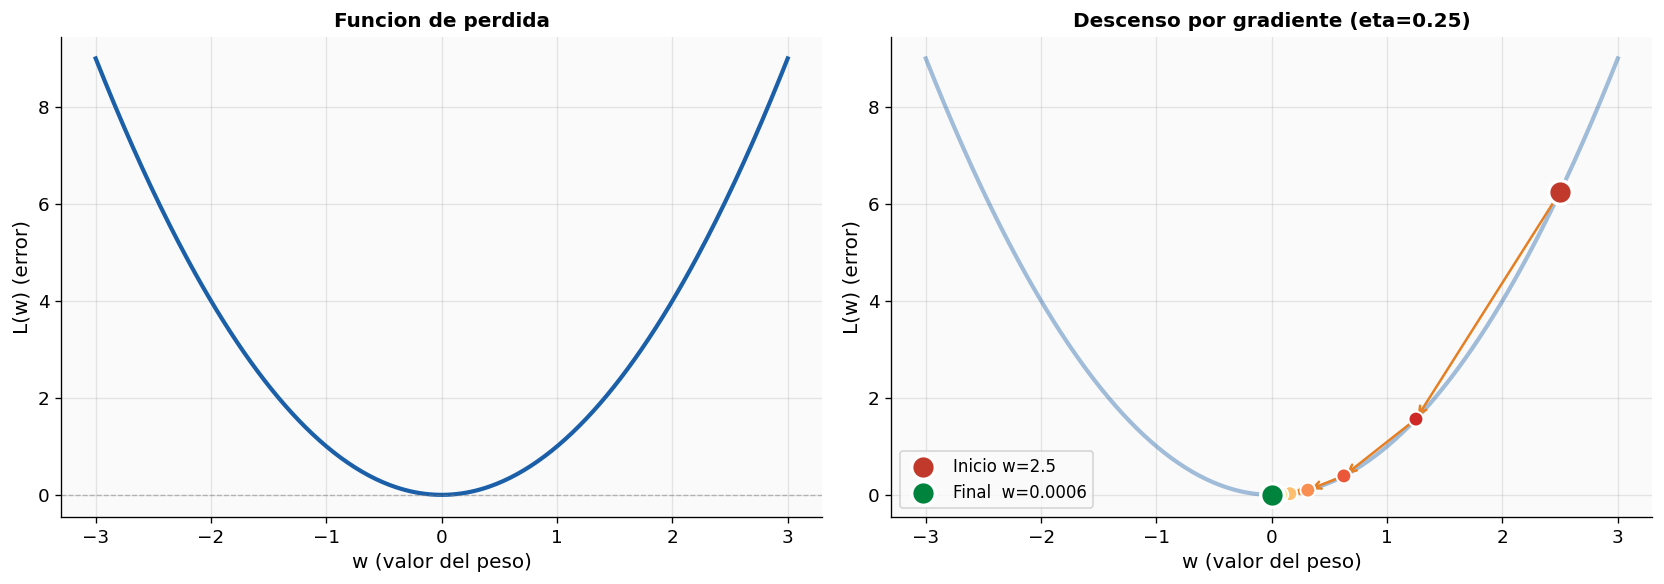

Paso 0:  w = 2.5000,  L = 6.2500,  gradiente = 5.0000
Paso 1:  w = 1.2500,  L = 1.5625
Paso final:  w = 0.000610  (optimo: w = 0.0)


In [2]:
# [OK] Descenso por gradiente: minimizar L(w) = w^2 (caso mas simple posible)

def L(w):     return w**2
def dL_dw(w): return 2*w

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: la funcion de perdida
w_vals = np.linspace(-3, 3, 300)
axes[0].plot(w_vals, L(w_vals), color=AZUL, linewidth=2.5, label="L(w) = w^2")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
axes[0].set_xlabel("w (valor del peso)", fontsize=12)
axes[0].set_ylabel("L(w) (error)", fontsize=12)
axes[0].set_title("Funcion de perdida", fontsize=12, fontweight="bold")

# Panel der: trayectoria del descenso por gradiente
w_vals = np.linspace(-3, 3, 300)
axes[1].plot(w_vals, L(w_vals), color=AZUL, linewidth=2.5, alpha=0.4)

eta  = 0.25
w    = 2.5
tray = [w]
for paso in range(12):
    grad = dL_dw(w)
    w    = w - eta * grad
    tray.append(w)

tray = np.array(tray)
axes[1].scatter(tray, L(tray), c=range(len(tray)), cmap="RdYlGn",
                s=80, zorder=6, edgecolors="white", linewidths=1.2)

for i in range(len(tray)-1):
    axes[1].annotate("", xy=(tray[i+1], L(tray[i+1])),
                     xytext=(tray[i], L(tray[i])),
                     arrowprops=dict(arrowstyle="->", color=NARANJA, lw=1.5))

axes[1].scatter(tray[0], L(tray[0]), s=200, color=ROJO, zorder=7,
                edgecolors="white", linewidths=2, label=f"Inicio w={tray[0]:.1f}")
axes[1].scatter(tray[-1], L(tray[-1]), s=200, color=VERDE, zorder=7,
                edgecolors="white", linewidths=2, label=f"Final  w={tray[-1]:.4f}")
axes[1].set_xlabel("w (valor del peso)", fontsize=12)
axes[1].set_ylabel("L(w) (error)", fontsize=12)
axes[1].set_title(f"Descenso por gradiente (eta={eta})", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)

plt.tight_layout(); plt.show()

print(f"Paso 0:  w = {2.5:.4f},  L = {L(2.5):.4f},  gradiente = {dL_dw(2.5):.4f}")
print(f"Paso 1:  w = {2.5 - eta*dL_dw(2.5):.4f},  L = {L(2.5-eta*dL_dw(2.5)):.4f}")
print(f"Paso final:  w = {tray[-1]:.6f}  (optimo: w = 0.0)")


## 3. Backpropagation: la regla de la cadena a escala

El descenso por gradiente necesita $\partial L / \partial w$ para **cada** peso.
En una red con millones de pesos, calcular eso uno por uno seria imposible.

Backpropagation resuelve esto usando la **regla de la cadena** del calculo:

Si la red tiene capas $L_1 \to L_2 \to \cdots \to L_k \to \text{perdida}$,
el gradiente en la capa $i$ se calcula **desde la salida hacia atras**:

$$\frac{\partial \text{perdida}}{\partial w_i} = \frac{\partial \text{perdida}}{\partial z_k} \cdot \frac{\partial z_k}{\partial z_{k-1}} \cdots \frac{\partial z_{i+1}}{\partial z_i} \cdot \frac{\partial z_i}{\partial w_i}$$

Cada factor es la derivada de **una sola capa** -- algo facil de calcular.
El truco esta en **reutilizar** los gradientes ya calculados mas a la derecha
en vez de recomputarlos desde cero para cada peso.

**Eso es backpropagation: propagacion eficiente del gradiente de derecha a izquierda.**

En la practica, frameworks como TensorFlow y PyTorch calculan esto
automaticamente con **diferenciacion automatica** (*autograd*).
Nosotros no necesitamos derivar nada a mano.

Pero para que backpropagation funcione, cada operacion de la red
debe ser **diferenciable**. Ahi entra el siguiente ingrediente: las funciones de activacion.


## 4. Funciones de activacion: la no linealidad esencial

Sin funciones de activacion, una red de $k$ capas con operaciones $W_k \mathbf{x} + b_k$
seria equivalente a **una sola transformacion lineal**
(el producto de matrices es todavia una matriz).
Las funciones de activacion introducen la **no linealidad** que permite aprender
patrones complejos.

Las tres mas importantes:

| Nombre | Formula | Rango | Uso tipico |
|--------|---------|-------|------------|
| **Sigmoide** | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $(0, 1)$ | Salida binaria (clasificacion) |
| **ReLU** | $\text{ReLU}(z) = \max(0, z)$ | $[0, \infty)$ | Capas ocultas (muy comun) |
| **Softmax** | $\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$ | $(0,1)$, suma=1 | Salida multiclase |

> **Por que ReLU domina en la practica?** Es casi perfectamente lineal (facil de optimizar),
> pero introduce la no linealidad clave en $z=0$. Ademas su derivada es 1 (para $z>0$)
> o 0 (para $z<0$) -- extremadamente barata de calcular durante backpropagation.


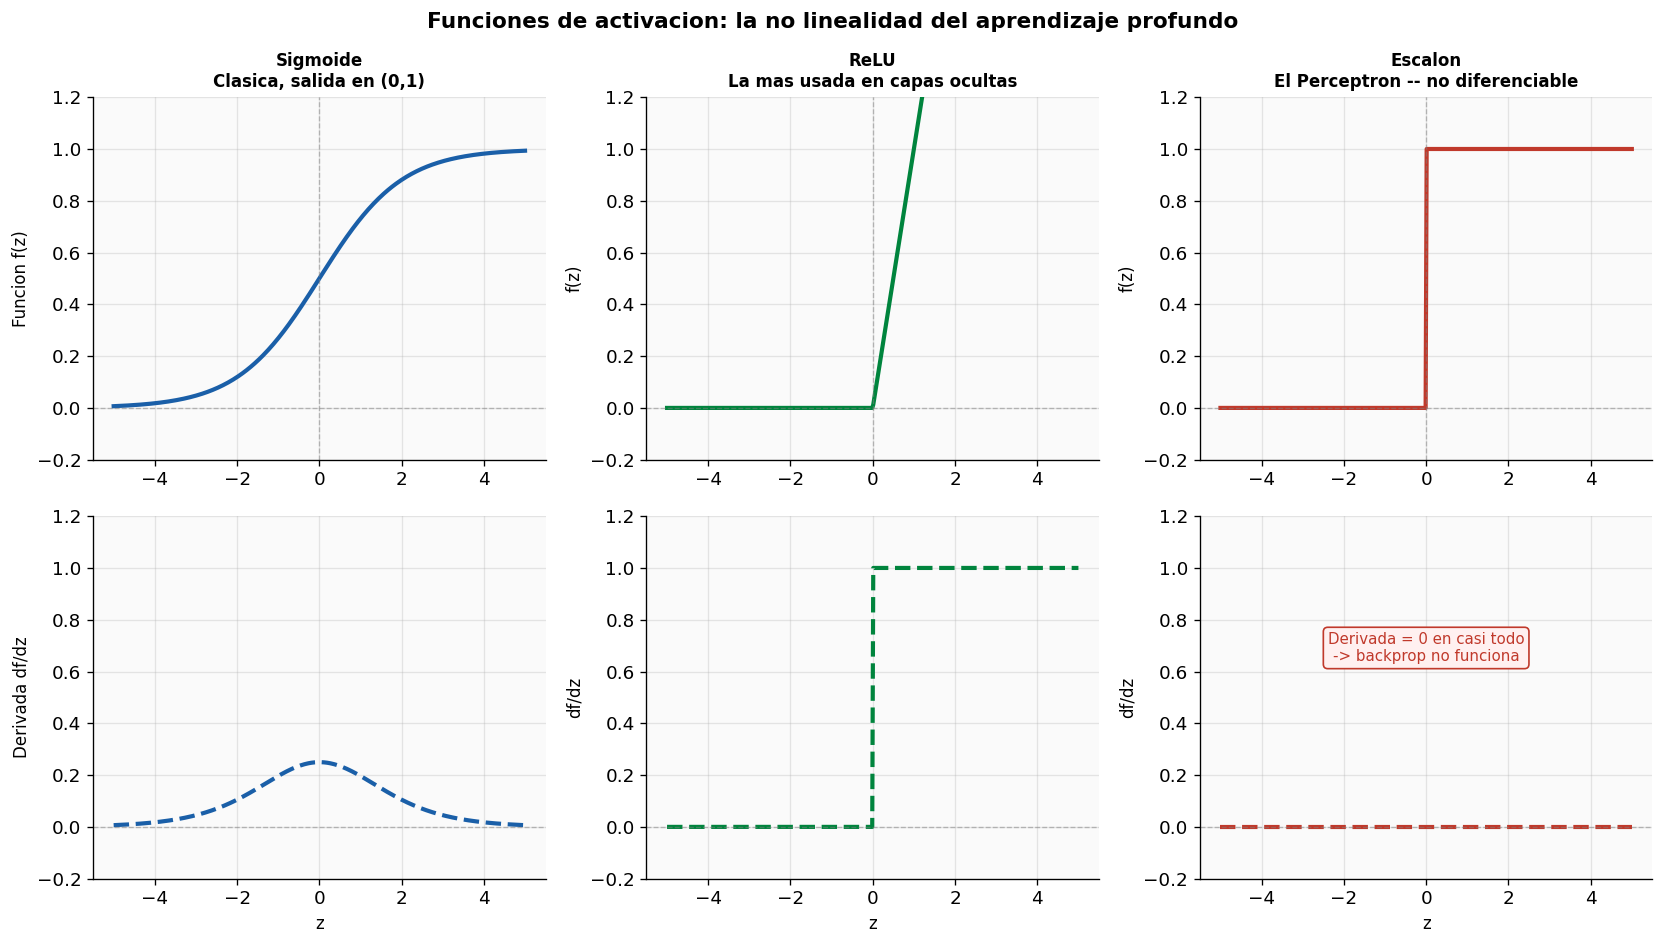

El escalon que usamos en el Perceptron tiene derivada = 0 en casi todo.
Backpropagation multiplica derivadas -- si alguna es 0, el gradiente muere.
Sigmoide y ReLU son diferenciables -> backpropagation funciona.


In [3]:
# [OK] Visualizar las funciones de activacion y sus derivadas

z = np.linspace(-5, 5, 400)

def sigmoide(z): return 1 / (1 + np.exp(-z))
def relu(z):     return np.maximum(0, z)
def softmax_1d(z): return np.exp(z) / np.sum(np.exp(z))  # version 1D

def d_sigmoide(z): s = sigmoide(z); return s * (1 - s)
def d_relu(z):     return (z > 0).astype(float)

activaciones = [
    ("Sigmoide",  sigmoide,  d_sigmoide,  AZUL,    "Clasica, salida en (0,1)"),
    ("ReLU",      relu,      d_relu,      VERDE,   "La mas usada en capas ocultas"),
    ("Escalon",   lambda z: (z > 0).astype(float),
                             lambda z: np.zeros_like(z),
                                          ROJO,    "El Perceptron -- no diferenciable"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, (nombre, f, df, color, desc) in enumerate(activaciones):
    # Fila superior: la funcion
    axes[0, col].plot(z, f(z), color=color, linewidth=2.5)
    axes[0, col].axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    axes[0, col].axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    axes[0, col].set_title(f"{nombre}\n{desc}", fontsize=10, fontweight="bold")
    axes[0, col].set_ylabel("f(z)", fontsize=10)
    axes[0, col].set_ylim(-0.2, 1.2)

    # Fila inferior: la derivada
    axes[1, col].plot(z, df(z), color=color, linewidth=2.5, linestyle="--")
    axes[1, col].axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    axes[1, col].set_ylabel("df/dz", fontsize=10)
    axes[1, col].set_xlabel("z", fontsize=10)
    axes[1, col].set_ylim(-0.2, 1.2)

    if nombre == "Escalon":
        axes[1, col].text(0.5, 0.6, "Derivada = 0 en casi todo\n-> backprop no funciona",
                          ha="center", transform=axes[1, col].transAxes,
                          fontsize=9, color=ROJO,
                          bbox=dict(boxstyle="round", facecolor="#fff0f0", edgecolor=ROJO))

axes[0, 0].set_ylabel("Funcion f(z)", fontsize=10)
axes[1, 0].set_ylabel("Derivada df/dz", fontsize=10)

plt.suptitle("Funciones de activacion: la no linealidad del aprendizaje profundo",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("El escalon que usamos en el Perceptron tiene derivada = 0 en casi todo.")
print("Backpropagation multiplica derivadas -- si alguna es 0, el gradiente muere.")
print("Sigmoide y ReLU son diferenciables -> backpropagation funciona.")

## 5. Anatomia de una red neuronal

Una red neuronal es una composicion de transformaciones:

```
Entrada x
    |
    v
[Capa densa 1]  z1 = W1 @ x  + b1     <- operacion lineal
                a1 = ReLU(z1)          <- activacion no lineal
    |
    v
[Capa densa 2]  z2 = W2 @ a1 + b2
                a2 = ReLU(z2)
    |
    v
[Capa de salida] z3 = W3 @ a2 + b3
                 y  = softmax(z3)      <- probabilidades de cada clase
    |
    v
[Perdida]  L = -log(y[clase_correcta])  <- cross-entropy
```

**Cada capa densa tiene dos tipos de parametros aprendibles:**

| Parametro | Forma | Rol |
|-----------|-------|-----|
| Matriz de pesos $W$ | `(n_salidas, n_entradas)` | Escala y rota el espacio |
| Sesgo $b$ | `(n_salidas,)` | Desplaza la frontera de decision |

Para una capa con 128 neuronas que recibe 784 entradas:
$W$ tiene $128 \times 784 = 100{,}352$ parametros,
mas 128 sesgos. **Solo en esta capa.**

> **La funcion de perdida** mide que tan equivocada esta la red.
> Para clasificacion multiclase se usa la **entropia cruzada** (*cross-entropy*):
> $$L = -\log\big(\hat{y}_{\text{clase correcta}}\big)$$
> Penaliza fuertemente cuando la red asigna poca probabilidad a la clase correcta.


In [4]:
# [Ejercicio 1] Implementar una capa densa en NumPy puro

def relu(z):
    return np.maximum(0, z)

def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-z))


class CapaDensa:
    def __init__(self, n_entradas, n_neuronas, activacion="relu"):
        # Inicializacion de He: escala los pesos segun el numero de entradas
        escala     = np.sqrt(2.0 / n_entradas)
        self.W     = np.random.randn(n_neuronas, n_entradas) * escala
        self.b     = np.zeros(n_neuronas)
        self.act   = activacion

    def forward(self, x):
        """
        Paso hacia adelante (forward pass).
        x: vector de entrada, forma (n_entradas,)
        Retorna: activacion de la capa
        """
        # ================================================
        # [Ejercicio] Completa el forward pass.
        # Paso 1: calcula z = W @ x + b
        # Paso 2: aplica la funcion de activacion
        #         si self.act == "relu"    -> usa relu(z)
        #         si self.act == "sigmoide"-> usa sigmoide(z)
        #         si self.act == "lineal"  -> retorna z directamente
        # ================================================
        z = np.dot(self.W,x) + self.b   # <- calcula la transformacion lineal

        if self.act == "relu":
            return relu(z)   # <- aplica relu
        elif self.act == "sigmoide":
            return sigmoide(z)   # <- aplica sigmoide
        else:             # lineal
            return z


# Verificacion: una red de 2 capas que resuelve XOR
# (mismos pesos del Notebook 02, ahora con la clase CapaDensa)

capa1 = CapaDensa(2, 2, activacion="sigmoide")
capa1.W = np.array([[20.0, 20.0], [20.0, 20.0]])
capa1.b = np.array([-10.0, -30.0])

capa2 = CapaDensa(2, 1, activacion="sigmoide")
capa2.W = np.array([[-20.0, 20.0]])
capa2.b = np.array([-10.0])

X_xor = [[0,0],[1,0],[0,1],[1,1]]
y_xor = [0, 1, 1, 0]

print("Red de 2 capas resolviendo XOR (si forward esta bien implementado):")
for xi, yi in zip(X_xor, y_xor):
    x_np = np.array(xi, dtype=float)
    a1   = capa1.forward(x_np)
    a2   = capa2.forward(a1)
    pred = int(a2[0] > 0.5) if a2 is not None else None
    estado = "[OK]" if pred == yi else "[!]"
    print(f"  XOR{tuple(xi)} -> {a2}  pred={pred}  esperado={yi}  {estado}")

Red de 2 capas resolviendo XOR (si forward esta bien implementado):
  XOR(0, 0) -> [4.53566699e-05]  pred=0  esperado=0  [OK]
  XOR(1, 0) -> [9.37463105e-14]  pred=0  esperado=1  [!]
  XOR(0, 1) -> [9.37463105e-14]  pred=0  esperado=1  [!]
  XOR(1, 1) -> [4.53566699e-05]  pred=0  esperado=0  [OK]


## 6. TensorFlow y Keras: hacer todo esto en 10 lineas

Implementar manualmente una red con backpropagation es instructivo,
pero en la practica usamos frameworks que:

1. **Calculan gradientes automaticamente** (autograd)
2. **Ejecutan en GPU** cuando esta disponible
3. **Incluyen optimizadores avanzados** (Adam, RMSProp, etc.)
4. **Gestionan los datos** en minilotes eficientemente

**TensorFlow** es el framework de Google. **Keras** es su API de alto nivel --
la que usaremos. Keras permite construir redes con una sintaxis muy legible.

### El optimizador Adam

En vez del descenso por gradiente basico ($w \leftarrow w - \eta \nabla L$),
usaremos **Adam** (*Adaptive Moment Estimation*).
Adam ajusta la tasa de aprendizaje de cada peso individualmente basandose
en el historial de gradientes. En la practica converge mucho mas rapido
que el descenso por gradiente estandar y es el optimizador por defecto
en casi toda la investigacion actual.

La diferencia entre SGD basico y Adam es analoga a la diferencia entre
RK4 y Euler: Adam usa informacion del pasado para dar mejores pasos.


In [5]:
# [OK] Nuestra primera red con TensorFlow/Keras
#      Resuelve XOR (el problema que no podia el Perceptron)

import tensorflow as tf
from tensorflow import keras

print(f"TensorFlow version: {tf.__version__}")

# Dataset XOR
X_xor = np.array([[0,0],[1,0],[0,1],[1,1]], dtype="float32")
y_xor = np.array([0, 1, 1, 0], dtype="float32")

# Definir la arquitectura
modelo_xor = keras.Sequential([
    keras.layers.Dense(4, activation="relu", input_shape=(2,)),  # capa oculta
    keras.layers.Dense(1, activation="sigmoid"),                  # capa de salida
])

# Compilar: elegir optimizador y funcion de perdida
modelo_xor.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Ver la arquitectura
modelo_xor.summary()


TensorFlow version: 2.20.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

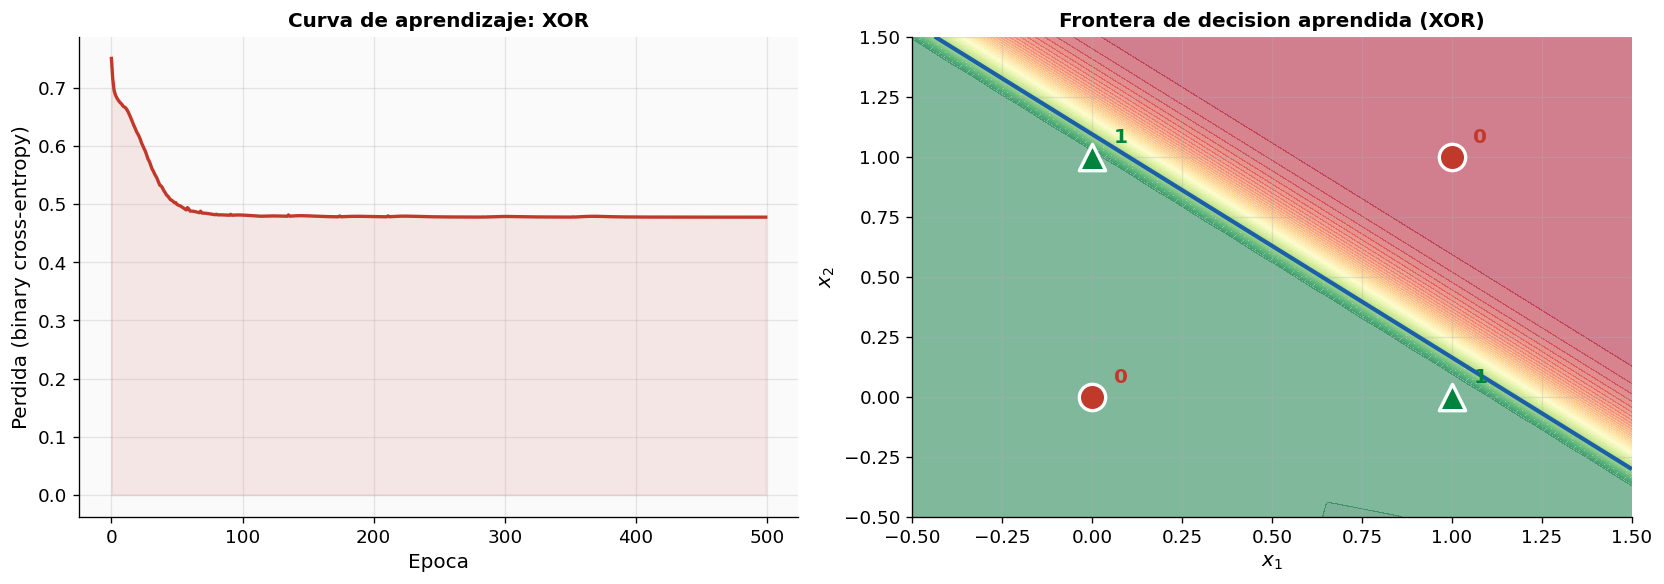

Predicciones finales:
  XOR(np.int64(0), np.int64(0)) = 1  (esperado 0)  [!]
  XOR(np.int64(1), np.int64(0)) = 1  (esperado 1)  [OK]
  XOR(np.int64(0), np.int64(1)) = 1  (esperado 1)  [OK]
  XOR(np.int64(1), np.int64(1)) = 0  (esperado 0)  [OK]

La frontera de decision ya no es una linea recta -- la red aprendio no linealidad.


In [6]:
# [OK] Entrenar la red en XOR y visualizar el aprendizaje

historia = modelo_xor.fit(
    X_xor, y_xor,
    epochs=500,
    verbose=0,        # silencioso -- graficamos nosotros
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de perdida
axes[0].plot(historia.history["loss"], color=ROJO, linewidth=2)
axes[0].set_xlabel("Epoca", fontsize=12)
axes[0].set_ylabel("Perdida (binary cross-entropy)", fontsize=12)
axes[0].set_title("Curva de aprendizaje: XOR", fontsize=12, fontweight="bold")
axes[0].fill_between(range(len(historia.history["loss"])),
                      historia.history["loss"], alpha=0.1, color=ROJO)

# Frontera de decision aprendida
x1r = np.linspace(-0.5, 1.5, 200)
x2r = np.linspace(-0.5, 1.5, 200)
xx1, xx2 = np.meshgrid(x1r, x2r)
grid = np.c_[xx1.ravel(), xx2.ravel()].astype("float32")
Z = modelo_xor.predict(grid, verbose=0).reshape(xx1.shape)

axes[1].contourf(xx1, xx2, Z, levels=50, cmap="RdYlGn", alpha=0.5)
axes[1].contour(xx1, xx2, Z, levels=[0.5], colors=[AZUL], linewidths=2.5)

for xi, yi in zip(X_xor, y_xor):
    color  = VERDE if yi == 1 else ROJO
    marker = "^"   if yi == 1 else "o"
    axes[1].scatter(xi[0], xi[1], c=color, marker=marker, s=250,
                    zorder=6, edgecolors="white", linewidths=2)
    axes[1].text(xi[0]+0.06, xi[1]+0.06, str(int(yi)), fontsize=12,
                 color=color, fontweight="bold")

axes[1].set_xlabel("$x_1$", fontsize=12); axes[1].set_ylabel("$x_2$", fontsize=12)
axes[1].set_title("Frontera de decision aprendida (XOR)", fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

# Verificar
preds = (modelo_xor.predict(X_xor, verbose=0) > 0.5).astype(int).flatten()
print("Predicciones finales:")
for xi, yi, pi in zip(X_xor, y_xor, preds):
    estado = "[OK]" if int(pi) == int(yi) else "[!]"
    print(f"  XOR{tuple(xi.astype(int))} = {pi}  (esperado {int(yi)})  {estado}")

print()
print("La frontera de decision ya no es una linea recta -- la red aprendio no linealidad.")


## 7. Para datos con estructura 2D: Flatten y Padding

Hasta ahora las entradas a la red eran **vectores** (una lista de numeros).
Pero las imagenes son **matrices** (filas y columnas de pixeles).
Una imagen de MNIST tiene forma $28 \times 28 = 784$ pixeles.

### Flatten: de imagen a vector

La capa `Flatten` simplemente "desenrolla" la matriz en un vector:

```
Imagen 28x28:           Vector 784:

[[ 0  0  0 ... ]        [0, 0, 0, ..., 255, 180, ..., 0]
 [ 0 255 180 ... ]                ^                ^
 [ 0  0  0 ... ]         fila 1 pegada     fila 2 pegada
 ...           ]
```

Matematicamente: si la imagen tiene forma $(H, W)$, Flatten la convierte en un vector de $H \times W$ elementos.

### Padding: para no perder bordes en redes convolucionales

Las **redes convolucionales** (CNNs) aplican filtros que se deslizan sobre la imagen.
Un filtro de $3 \times 3$ sobre una imagen de $28 \times 28$ produce una imagen de $26 \times 26$ -- **pierde bordes**.

El **padding** agrega filas y columnas de ceros alrededor:

```
Sin padding (valid):     Con padding = "same":

  Entrada: 5x5           Entrada: 5x5  (con un borde de ceros)
  Filtro:  3x3           0 0 0 0 0 0 0
  Salida:  3x3           0 . . . . . 0
                         0 . . . . . 0
                         0 . . . . . 0
                         0 . . . . . 0
                         0 0 0 0 0 0 0
                         Filtro: 3x3
                         Salida: 5x5  (mismo tamano)
```

| Opcion | Resultado | Uso |
|--------|-----------|-----|
| `padding="valid"` | Salida mas pequena que entrada | Por defecto |
| `padding="same"` | Salida del **mismo tamano** que entrada | Redes profundas |


/tmp/ipykernel_2194/4191444939.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


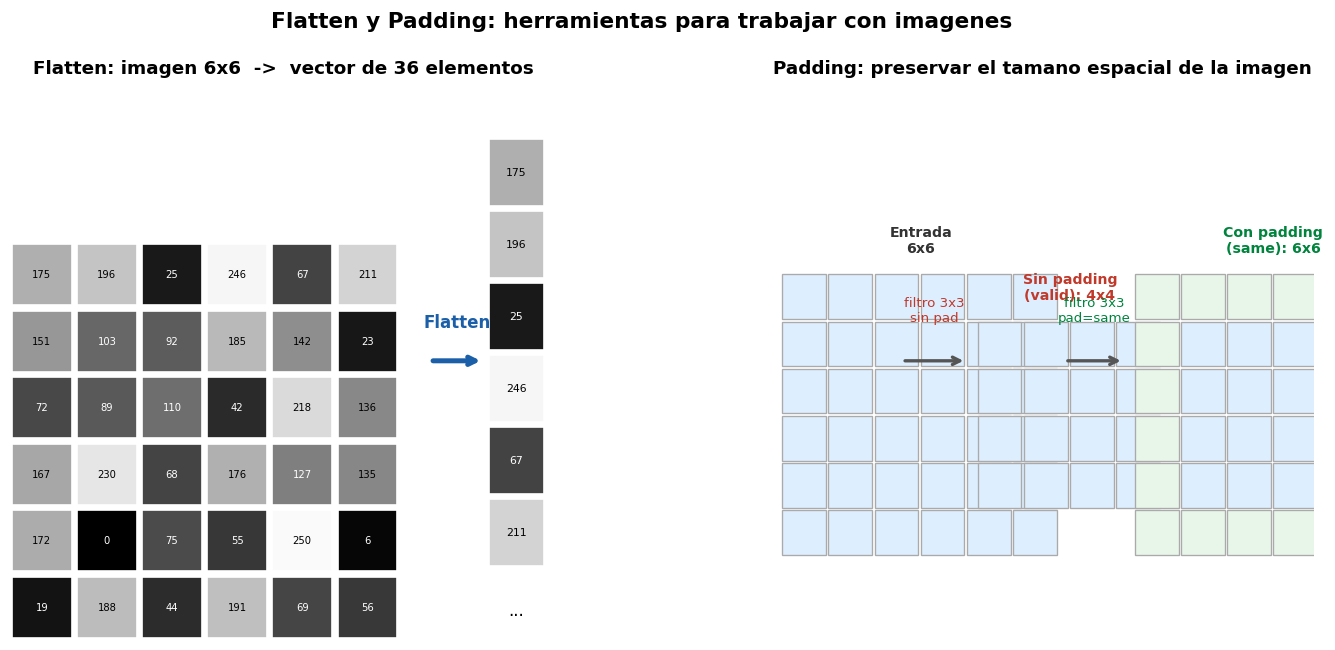

In [7]:
# [OK] Visualizar Flatten y Padding

fig = plt.figure(figsize=(14, 6))
gs  = GridSpec(1, 2, figure=fig, wspace=0.4)

# ── Panel izquierdo: Flatten ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("white"); ax1.axis("off")

# Simular un fragmento de imagen 6x6
np.random.seed(7)
img = np.random.randint(0, 256, (6, 6))

# Dibujar la imagen como cuadricula
for i in range(6):
    for j in range(6):
        val  = img[i, j]
        color = plt.cm.gray(val/255)
        ax1.add_patch(plt.Rectangle((j*0.12, (5-i)*0.12), 0.11, 0.11,
                                     facecolor=color, edgecolor="white", linewidth=1,
                                     transform=ax1.transAxes))
        ax1.text(j*0.12+0.055, (5-i)*0.12+0.055, str(val),
                 ha="center", va="center", fontsize=6,
                 color="white" if val < 128 else "black",
                 transform=ax1.transAxes)

ax1.annotate("", xy=(0.87, 0.5), xytext=(0.77, 0.5),
             xycoords="axes fraction",
             arrowprops=dict(arrowstyle="->", color=AZUL, lw=3))
ax1.text(0.82, 0.56, "Flatten", ha="center", fontsize=10,
         color=AZUL, fontweight="bold", transform=ax1.transAxes)

# Vector resultante (primeras 6 values)
vec = img.flatten()
for k, v in enumerate(vec[:6]):
    ax1.add_patch(plt.Rectangle((0.88, 0.78 - k*0.13), 0.1, 0.12,
                                 facecolor=plt.cm.gray(v/255),
                                 edgecolor="white", linewidth=1,
                                 transform=ax1.transAxes))
    ax1.text(0.93, 0.78 - k*0.13 + 0.06, str(v), ha="center", va="center",
             fontsize=6.5, color="white" if v < 128 else "black",
             transform=ax1.transAxes)
ax1.text(0.93, 0.78 - 6*0.13 + 0.04, "...", ha="center",
         fontsize=10, transform=ax1.transAxes)

ax1.set_title("Flatten: imagen 6x6  ->  vector de 36 elementos",
              fontsize=11, fontweight="bold")

# ── Panel derecho: Padding ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("white"); ax2.axis("off")

# Grilla sin padding (4x4 valida de una imagen 6x6 con filtro 3x3)
for caso, x0, titulo, n_out, borde_color in [
    ("Entrada\n6x6", 0.02, "", 6, "#333"),
    ("Sin padding\n(valid): 4x4", 0.38, "", 4, ROJO),
    ("Con padding\n(same): 6x6", 0.67, "", 6, VERDE),
]:
    n = 6 if "Entrada" in caso or "same" in caso else 4
    sz = 0.085
    offset_y = (6 - n) * sz / 2

    for i in range(n):
        for j in range(n):
            fc = "#e8f5e9" if "same" in caso and (i==0 or i==n-1 or j==0 or j==n-1) else "#ddeeff"
            ax2.add_patch(plt.Rectangle(
                (x0 + j*sz, 0.15 + offset_y + (n-1-i)*sz), sz*0.95, sz*0.95,
                facecolor=fc, edgecolor="#aaa", linewidth=0.8,
                transform=ax2.transAxes))

    lbl_y = 0.15 + offset_y + n*sz + 0.03
    ax2.text(x0 + n*sz/2, lbl_y, caso, ha="center", va="bottom",
             fontsize=8.5, fontweight="bold", color=borde_color,
             transform=ax2.transAxes)

# Flechas
for x_s, x_e in [(0.24, 0.36), (0.54, 0.65)]:
    ax2.annotate("", xy=(x_e, 0.5), xytext=(x_s, 0.5),
                 xycoords="axes fraction",
                 arrowprops=dict(arrowstyle="->", color="#555", lw=2))

ax2.text(0.30, 0.57, "filtro 3x3\nsin pad", ha="center", fontsize=8,
         color=ROJO, transform=ax2.transAxes)
ax2.text(0.595, 0.57, "filtro 3x3\npad=same", ha="center", fontsize=8,
         color=VERDE, transform=ax2.transAxes)

ax2.set_title("Padding: preservar el tamano espacial de la imagen",
              fontsize=11, fontweight="bold")

plt.suptitle("Flatten y Padding: herramientas para trabajar con imagenes",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


In [8]:
# [Ejercicio 2] Construir y entender una red completa con Keras
#
# Queremos una red para clasificar imagenes de 28x28 pixeles
# en 10 categorias (como MNIST, que veremos en el NB04).
#
# Arquitectura pedida:
#   1. Flatten (de 28x28 a 784)
#   2. Capa densa oculta con 128 neuronas y activacion ReLU
#   3. Capa densa oculta con 64 neuronas y activacion ReLU
#   4. Capa de salida con 10 neuronas y activacion softmax

# ================================================
# [Ejercicio] Completa la arquitectura.
# Cada linea comentada es un componente que debes agregar.
# Usa keras.layers.Flatten(), keras.layers.Dense(...)
# ================================================

modelo = keras.Sequential([
    keras.layers.Flatten(input_shape = (28,28)),# <- Flatten: convierte (28,28) en (784,)
    keras.layers.Dense(128, activation = 'relu', input_shape = (784)),# <- Dense: 128 neuronas, relu
    keras.layers.Dense(64, activation = 'relu', input_shape = (784,128)),# <- Dense: 64 neuronas, relu
    keras.layers.Dense(10, activation = 'softmax')# <- Dense: 10 neuronas (una por clase), softmax
])

modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # para etiquetas enteras (0-9)
    metrics=["accuracy"],
)

# Esto deberia mostrar la arquitectura con ~101,770 parametros totales
modelo.summary()

# Verificacion: la salida debe tener forma (1, 10)
x_prueba = np.random.rand(1, 28, 28).astype("float32")
try:
    y_prueba = modelo.predict(x_prueba, verbose=0)
    print(f"\nForma de la salida: {y_prueba.shape}  (esperado: (1, 10))")
    print(f"Suma de probabilidades: {y_prueba.sum():.4f}  (debe ser 1.0 -- es softmax)")
except Exception as e:
    print(f"[!] Error: {e}")
    print("    Revisa que los layers esten en el orden correcto y bien configurados.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Forma de la salida: (1, 10)  (esperado: (1, 10))
Suma de probabilidades: 1.0000  (debe ser 1.0 -- es softmax)


In [9]:
# [OK] Entender de donde vienen los parametros

print("Desglose manual de parametros de la red:")
print()

capas_info = [
    ("Flatten",       "(28,28) -> (784,)",   0,           0,          0),
    ("Dense-128 ReLU","(784,)  -> (128,)",   784*128,     128,        784*128+128),
    ("Dense-64  ReLU","(128,)  -> (64,)",    128*64,      64,         128*64+64),
    ("Dense-10 Softmax","(64,) -> (10,)",    64*10,       10,         64*10+10),
]

total = 0
print("{:<22} {:<20} {:>10} {:>10} {:>10}".format("Capa","Forma","W params","b params","Total"))
print("-" * 76)
for nombre, forma, w_p, b_p, tot in capas_info:
    print(f"{nombre:<22} {forma:<20} {w_p:>10,} {b_p:>10,} {tot:>10,}")
    total += tot
print("-" * 76)
print("{:<22} {:<20} {:>10} {:>10} {:>10,}".format("TOTAL","","","",total))
print()
print(f"Cada parametro es un numero float32 (4 bytes).")
print(f"Tamano total del modelo: {total * 4 / 1024:.1f} KB = {total * 4 / 1024**2:.2f} MB")
print()
print("Perspectiva: GPT-3 tiene 175,000,000,000 parametros. (~350 GB en float32)")


Desglose manual de parametros de la red:

Capa                   Forma                  W params   b params      Total
----------------------------------------------------------------------------
Flatten                (28,28) -> (784,)             0          0          0
Dense-128 ReLU         (784,)  -> (128,)       100,352        128    100,480
Dense-64  ReLU         (128,)  -> (64,)          8,192         64      8,256
Dense-10 Softmax       (64,) -> (10,)              640         10        650
----------------------------------------------------------------------------
TOTAL                                                                109,386

Cada parametro es un numero float32 (4 bytes).
Tamano total del modelo: 427.3 KB = 0.42 MB

Perspectiva: GPT-3 tiene 175,000,000,000 parametros. (~350 GB en float32)


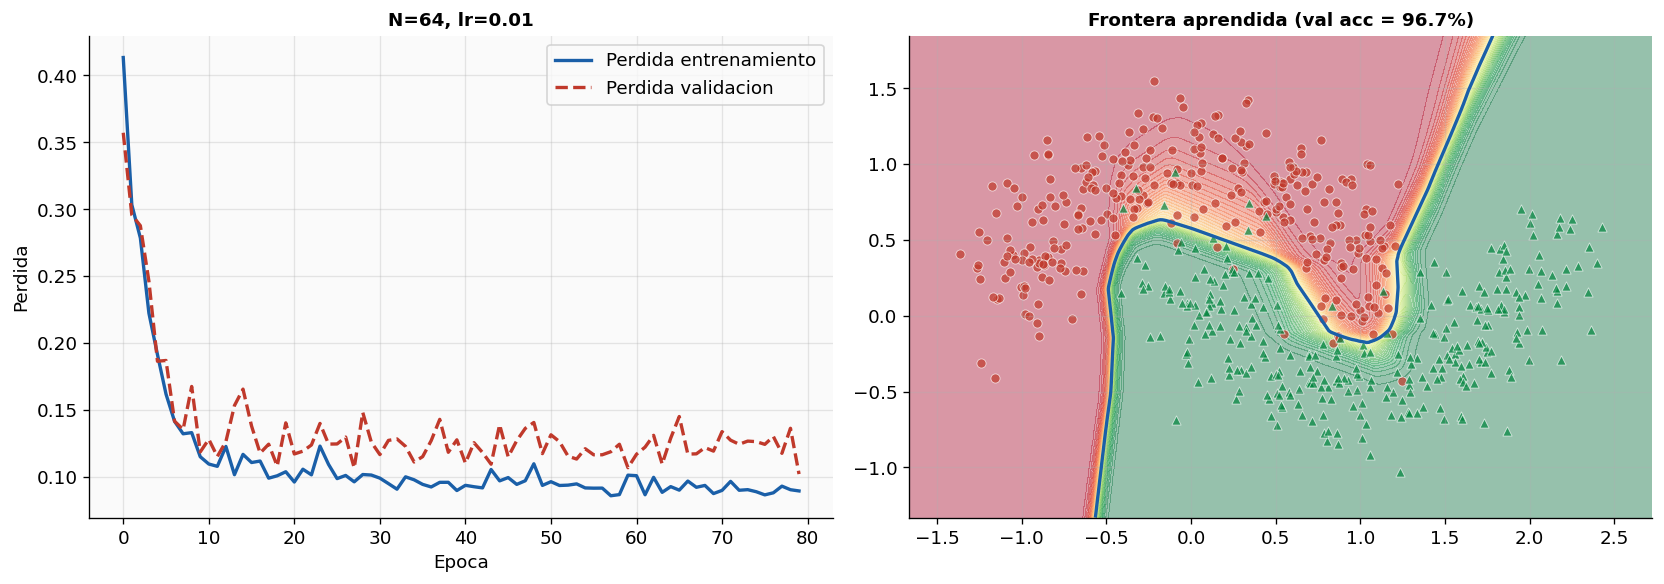

In [10]:
# [Ejercicio 3] Explorar el efecto de los hiperparametros
#
# Los "hiperparametros" son los parametros que TU eliges antes de entrenar:
#   - Numero de neuronas por capa
#   - Tasa de aprendizaje
#   - Numero de epocas
#
# Usamos un dataset de clasificacion sintetico para experimentar rapido.

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_moon, y_moon = make_moons(n_samples=600, noise=0.2, random_state=42)
X_moon = X_moon.astype("float32")
y_moon = y_moon.astype("float32")
X_tr, X_val, y_tr, y_val = train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)

# ================================================
# [Ejercicio] Modifica estos hiperparametros y
# observa como cambia la curva de aprendizaje:
#
# RETO: encuentra la combinacion que da >95% en val
# en menos de 100 epocas.
# ================================================
N_NEURONAS    = 64    # <- prueba: 4, 8, 16, 64
TASA_APREN    = 0.01  # <- prueba: 0.001, 0.01, 0.1
N_EPOCAS      = 80    # <- prueba: 30, 80, 200

modelo_moon = keras.Sequential([
    keras.layers.Dense(N_NEURONAS, activation="relu", input_shape=(2,)),
    keras.layers.Dense(N_NEURONAS, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])
modelo_moon.compile(
    optimizer=keras.optimizers.Adam(learning_rate=TASA_APREN),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
hist_moon = modelo_moon.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                             epochs=N_EPOCAS, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de aprendizaje
axes[0].plot(hist_moon.history["loss"],     color=AZUL,  label="Perdida entrenamiento")
axes[0].plot(hist_moon.history["val_loss"], color=ROJO,  label="Perdida validacion", linestyle="--")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Perdida")
axes[0].set_title(f"N={N_NEURONAS}, lr={TASA_APREN}", fontsize=11, fontweight="bold")
axes[0].legend()

# Frontera de decision
x1r = np.linspace(X_moon[:,0].min()-0.3, X_moon[:,0].max()+0.3, 300)
x2r = np.linspace(X_moon[:,1].min()-0.3, X_moon[:,1].max()+0.3, 300)
xx1, xx2 = np.meshgrid(x1r, x2r)
grid_moon = np.c_[xx1.ravel(), xx2.ravel()].astype("float32")
Z_moon = modelo_moon.predict(grid_moon, verbose=0).reshape(xx1.shape)
axes[1].contourf(xx1, xx2, Z_moon, levels=50, cmap="RdYlGn", alpha=0.4)
axes[1].contour(xx1, xx2, Z_moon, levels=[0.5], colors=[AZUL], linewidths=2)
for clase, color, marker in [(0, ROJO, "o"), (1, VERDE, "^")]:
    mask = y_moon == clase
    axes[1].scatter(X_moon[mask, 0], X_moon[mask, 1], c=color, marker=marker,
                    s=30, alpha=0.7, edgecolors="white", linewidths=0.5)

val_acc = hist_moon.history["val_accuracy"][-1]
axes[1].set_title(f"Frontera aprendida (val acc = {val_acc:.1%})",
                   fontsize=11, fontweight="bold")

plt.tight_layout(); plt.show()


## 8. Resumen y puente hacia el Notebook 04

### Lo que aprendimos

| Concepto | Lo que aprendimos |
|----------|------------------|
| **Gradiente** | Vector de derivadas parciales: indica como cambia el error con cada peso |
| **Descenso por gradiente** | Actualizar pesos en direccion opuesta al gradiente: $w -= \eta \nabla L$ |
| **Backpropagation** | Regla de la cadena aplicada eficientemente de derecha a izquierda |
| **Funciones de activacion** | Introducen no linealidad; deben ser diferenciables para backprop |
| **ReLU** | La activacion mas usada en capas ocultas: rapida y efectiva |
| **Softmax** | Convierte la salida en probabilidades que suman 1 |
| **Flatten** | Desenrolla una imagen (matriz) en un vector para la capa densa |
| **Padding** | Preserva las dimensiones espaciales al aplicar filtros convolucionales |
| **Keras Sequential** | API de alto nivel para definir redes en pocas lineas |
| **Adam** | Optimizador que adapta la tasa de aprendizaje por peso |

---

### La pregunta que abre el Notebook 04

Sabemos construir redes y entrenarlas. Pero para entrenarlas bien necesitamos datos.
**Muchos datos etiquetados**.

Uno de los datasets que hizo posible el Deep Learning moderno es **MNIST**:
70,000 imagenes de digitos escritos a mano, con su etiqueta correcta.

En el Notebook 04 exploraremos ese dataset, veremos que significa "aprender"
a clasificar imagenes, y sentaremos las bases para reproducir los resultados
del paper de Neural ODEs en el Notebook 05.

---

### Siguiente: Notebook 04 -- La base de datos MNIST

---

*Analisis Numerico  |  Universidad Nacional de Colombia  |  Prof. Carlos Manuel Orrego Franco*
